<a href="https://colab.research.google.com/github/duxihw/BC9_3TA_KPOBb_MHE/blob/main/Laba_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа I. Асимптотическая сложность

**Выполнил:** Емельянов Дмитрий Алексеневич  
**Группа:** Б02-502  
**Дата:** 05.03.2026

## Задача 1. Поиск.

### Код C++

In [ ]:
%%writefile lab1.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <random>
#include <algorithm>
#include <fstream>

// Линейный поиск
bool linear_search(const std::vector<int>& arr, int key) {
    for (int x : arr) {
        if (x == key) return true;
    }
    return false;
}

// Бинарный поиск (массив должен быть отсортирован)
bool binary_search(const std::vector<int>& arr, int key) {
    int left = 0, right = arr.size() - 1;
    while (left <= right) {
        int mid = left + (right - left) / 2;
        if (arr[mid] == key) return true;
        if (arr[mid] < key) left = mid + 1;
        else right = mid - 1;
    }
    return false;
}

int main() {
    std::vector<int> sizes = {100, 500, 1000, 5000, 10000, 50000, 100000, 500000, 1000000};
    // std::random_device rd;
    // std::mt19937 gen(rd());
    unsigned seed = 8080;
    std::default_random_engine gen(seed);
    std::uniform_int_distribution<int> dist(0, 1'000'000);

    std::ofstream file_linear("data/linear_search.txt");
    std::ofstream file_binary("data/binary_search.txt");

    for (int N : sizes) {
        // Создаём массив случайных чисел
        std::vector<int> arr(N);
        for (int i = 0; i < N; ++i) arr[i] = dist(gen);

        // Для бинарного поиска нужна отсортированная копия
        std::vector<int> sorted_arr = arr;
        std::sort(sorted_arr.begin(), sorted_arr.end());


        // Измерение линейного поиска
        auto start = std::chrono::steady_clock::now();
        for (int r = 0; r < 10'000; ++r) {
            // Случайный ключ (средний случай)
            linear_search(arr, dist(gen));
        }
        auto end = std::chrono::steady_clock::now();
        auto time_linear = std::chrono::duration_cast<std::chrono::milliseconds>(end - start).count();

        // Измерение линейного поиска (худший случай, key=1'000'000)
        start = std::chrono::steady_clock::now();
        for (int r = 0; r < 10'000; ++r) {
            linear_search(arr, 1'000'000);
        }
        end = std::chrono::steady_clock::now();
        auto time_linear_bad = std::chrono::duration_cast<std::chrono::milliseconds>(end - start).count();


        // Измерение бинарного поиска
        start = std::chrono::steady_clock::now();
        for (int r = 0; r < 1'000'000; ++r) {
            // Случайный ключ (средний случай)
            binary_search(sorted_arr, dist(gen));
        }
        end = std::chrono::steady_clock::now();
        auto time_binary = std::chrono::duration_cast<std::chrono::milliseconds>(end - start).count();

        // Измерение бинарного поиска (худший случай, key=1'000'000)
        start = std::chrono::steady_clock::now();
        for (int r = 0; r < 1'000'000; ++r) {
            binary_search(sorted_arr, 1'000'000);
        }
        end = std::chrono::steady_clock::now();
        auto time_binary_bad = std::chrono::duration_cast<std::chrono::milliseconds>(end - start).count();

        file_linear << N << " " << time_linear << " " << time_linear_bad << std::endl;
        file_binary << N << " " << time_binary << " " << time_binary_bad << std::endl;

        std::cout << "N = " << N << " done" << std::endl;
    }

    file_linear.close();
    file_binary.close();
    return 0;
}

Overwriting lab1.cpp


In [ ]:
!g++ lab1.cpp -o lab1
!./lab1

N = 100 done
N = 500 done
N = 1000 done
N = 5000 done
N = 10000 done
N = 50000 done
N = 100000 done
N = 500000 done
N = 1000000 done


### Визуализация результатов (Python)

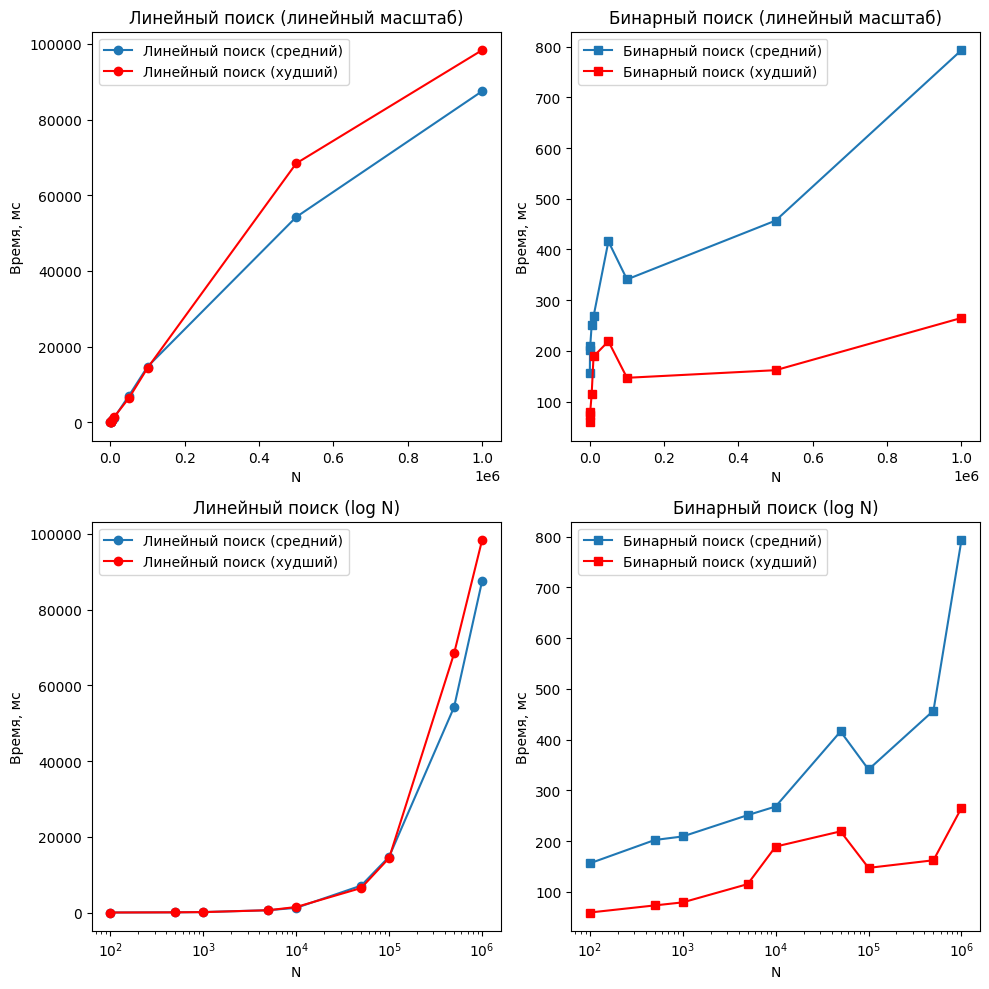

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Загрузка данных (ожидается три столбца: N, время_среднее, время_худшее)
data_lin = np.loadtxt('linear_search.txt')
data_bin = np.loadtxt('binary_search.txt')

N_lin, T_lin, T_lin_bad = data_lin[:, 0], data_lin[:, 1], data_lin[:, 2]
N_bin, T_bin, T_bin_bad = data_bin[:, 0], data_bin[:, 1], data_bin[:, 2]

# Создание фигуры с квадратными подграфиками (2x2, общий размер 10x10 дюймов)
plt.figure(figsize=(10, 10))

# Линейный масштаб для линейного поиска
plt.subplot(2, 2, 1)
plt.plot(N_lin, T_lin, 'o-', label='Линейный поиск (средний)')
plt.plot(N_lin, T_lin_bad, 'ro-', label='Линейный поиск (худший)')
plt.xlabel('N')
plt.ylabel('Время, мс')
plt.legend()
plt.title('Линейный поиск (линейный масштаб)')

# Линейный масштаб для бинарного поиска
plt.subplot(2, 2, 2)
plt.plot(N_bin, T_bin, 's-', label='Бинарный поиск (средний)')
plt.plot(N_bin, T_bin_bad, 'rs-', label='Бинарный поиск (худший)')
plt.xlabel('N')
plt.ylabel('Время, мс')
plt.legend()
plt.title('Бинарный поиск (линейный масштаб)')

# Логарифмическая шкала по x для линейного поиска
plt.subplot(2, 2, 3)
plt.semilogx(N_lin, T_lin, 'o-', label='Линейный поиск (средний)')
plt.semilogx(N_lin, T_lin_bad, 'ro-', label='Линейный поиск (худший)')
plt.xlabel('N')
plt.ylabel('Время, мс')
plt.legend()
plt.title('Линейный поиск (log N)')

# Логарифмическая шкала по x для бинарного поиска
plt.subplot(2, 2, 4)
plt.semilogx(N_bin, T_bin, 's-', label='Бинарный поиск (средний)')
plt.semilogx(N_bin, T_bin_bad, 'rs-', label='Бинарный поиск (худший)')
plt.xlabel('N')
plt.ylabel('Время, мс')
plt.legend()
plt.title('Бинарный поиск (log N)')

plt.tight_layout()
plt.savefig('lab1_plots.png', dpi=300, bbox_inches='tight')  # сохранение в файл
plt.show()


## Задача 2. Сумма двух (6–7 баллов)

### Код C++

In [ ]:
%%writefile lab2.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <random>
#include <algorithm>
#include <fstream>

// Полный перебор O(N^2)
bool two_sum_bruteforce(const std::vector<int>& arr, int target) {
    int n = arr.size();
    for (int i = 0; i < n; ++i) {
        for (int j = i + 1; j < n; ++j) {
            if (arr[i] + arr[j] == target) return true;
        }
    }
    return false;
}

// Два указателя для отсортированного массива O(N)
bool two_sum_sorted(const std::vector<int>& arr, int target) {
    int left = 0, right = arr.size() - 1;
    while (left < right) {
        int sum = arr[left] + arr[right];
        if (sum == target) return true;
        if (sum < target) ++left;
        else --right;
    }
    return false;
}

int main() {
    std::vector<int> sizes = {100, 500, 1000, 5000, 10000};
    // std::random_device rd;
    // std::mt19937 gen(rd());
    unsigned seed = 8080;
    std::default_random_engine gen(seed);
    std::uniform_int_distribution<int> dist(0, 100'000);

    std::ofstream file_brute("sum_bruteforce.txt");
    std::ofstream file_linear("sum_linear.txt");

    for (int N : sizes) {
        // Создаём массив случайных чисел
        std::vector<int> arr(N);
        for (int i = 0; i < N; ++i) arr[i] = dist(gen);

        // Для линейного алгоритма нужна отсортированная копия
        std::vector<int> sorted_arr = arr;
        std::sort(sorted_arr.begin(), sorted_arr.end());

        // Измерение полного перебора
        auto start = std::chrono::steady_clock::now();
        for (int r = 0; r < 10'000; ++r) {
            two_sum_bruteforce(arr, dist(gen));
        }
        auto end = std::chrono::steady_clock::now();
        auto time_brute = std::chrono::duration_cast<std::chrono::milliseconds>(end - start).count();

        // Измерение полного перебора (худший случай, key=-1)
        start = std::chrono::steady_clock::now();
        for (int r = 0; r < 10'000; ++r) {
            two_sum_bruteforce(arr, -1);
        }
        end = std::chrono::steady_clock::now();
        auto time_brute_bad = std::chrono::duration_cast<std::chrono::milliseconds>(end - start).count();


        // Измерение линейного алгоритма
        start = std::chrono::steady_clock::now();
        for (int r = 0; r < 100'000; ++r) {
            two_sum_sorted(sorted_arr, dist(gen));
        }
        end = std::chrono::steady_clock::now();
        auto time_linear = std::chrono::duration_cast<std::chrono::milliseconds>(end - start).count();

        // Измерение линейного алгоритма (худший случай, key=-1)
        start = std::chrono::steady_clock::now();
        for (int r = 0; r < 100'000; ++r) {
            two_sum_sorted(sorted_arr, -1);
        }
        end = std::chrono::steady_clock::now();
        auto time_linear_bad = std::chrono::duration_cast<std::chrono::milliseconds>(end - start).count();

        file_brute << N << " " << time_brute << " " << time_brute_bad << std::endl;
        file_linear << N << " " << time_linear << " " << time_linear_bad << std::endl;

        std::cout << "N = " << N << " done" << std::endl;
    }

    file_brute.close();
    file_linear.close();
    return 0;
}

Overwriting lab2.cpp


In [ ]:
!g++ lab2.cpp -o lab2
!./lab2

N = 100 done
N = 500 done
N = 1000 done
N = 5000 done
N = 10000 done


### Визуализация результатов (Python)

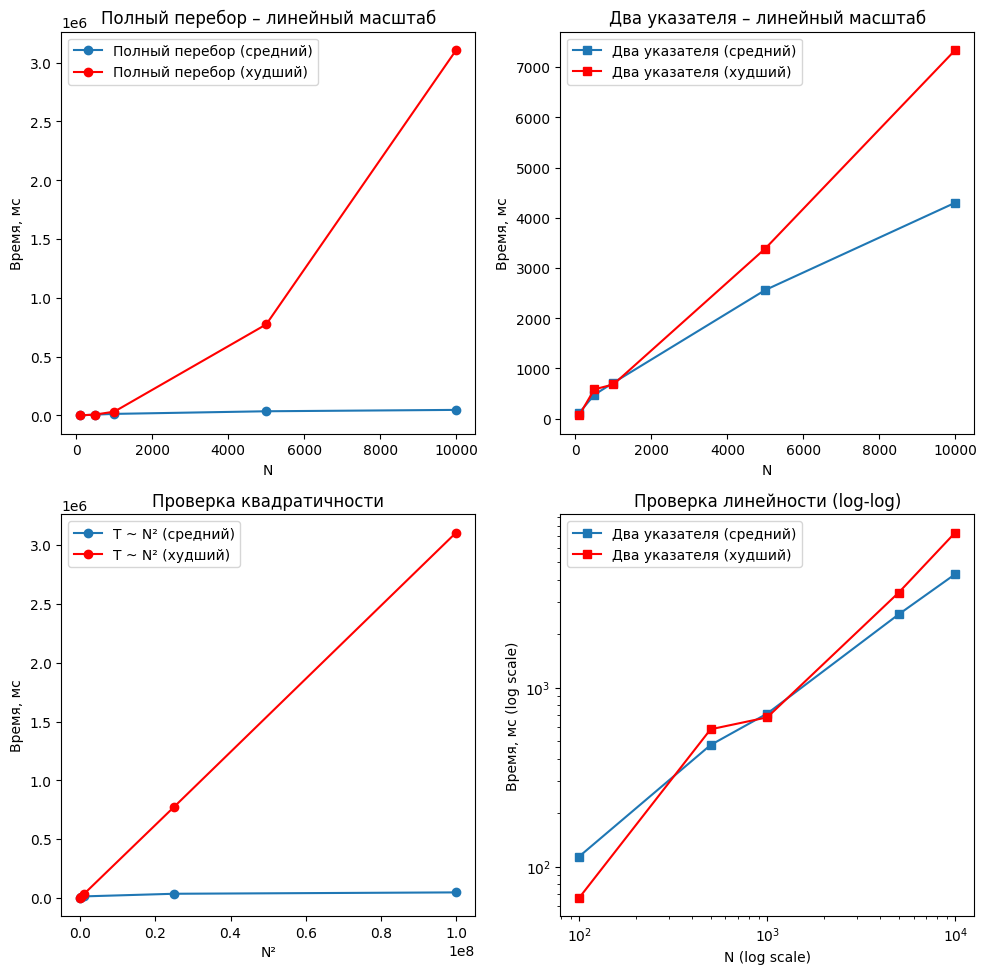

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Загрузка данных (предполагается три столбца: N, среднее время, худшее время)
data_bf = np.loadtxt('sum_bruteforce.txt')
data_lin = np.loadtxt('sum_linear.txt')

N_bf, T_bf, T_bf_bad = data_bf[:, 0], data_bf[:, 1], data_bf[:, 2]
N_lin, T_lin, T_lin_bad = data_lin[:, 0], data_lin[:, 1], data_lin[:, 2]

# Фигура 10x10 дюймов для квадратных подграфиков 2x2
plt.figure(figsize=(10, 10))

# График 1: полный перебор в линейном масштабе
plt.subplot(2, 2, 1)
plt.plot(N_bf, T_bf, 'o-', label='Полный перебор (средний)')
plt.plot(N_bf, T_bf_bad, 'ro-', label='Полный перебор (худший)')
plt.xlabel('N')
plt.ylabel('Время, мс')
plt.legend()
plt.title('Полный перебор – линейный масштаб')

# График 2: линейный алгоритм (два указателя) в линейном масштабе
plt.subplot(2, 2, 2)
plt.plot(N_lin, T_lin, 's-', label='Два указателя (средний)')
plt.plot(N_lin, T_lin_bad, 'rs-', label='Два указателя (худший)')
plt.xlabel('N')
plt.ylabel('Время, мс')
plt.legend()
plt.title('Два указателя – линейный масштаб')

# График 3: проверка квадратичности – зависимость времени от N²
plt.subplot(2, 2, 3)
plt.plot(N_bf**2, T_bf, 'o-', label='T ~ N² (средний)')
plt.plot(N_bf**2, T_bf_bad, 'ro-', label='T ~ N² (худший)')
plt.xlabel('N²')
plt.ylabel('Время, мс')
plt.legend()
plt.title('Проверка квадратичности')

# График 4: проверка линейности в логарифмическом масштабе
plt.subplot(2, 2, 4)
plt.loglog(N_lin, T_lin, 's-', label='Два указателя (средний)')
plt.loglog(N_lin, T_lin_bad, 'rs-', label='Два указателя (худший)')
plt.xlabel('N (log scale)')
plt.ylabel('Время, мс (log scale)')
plt.legend()
plt.title('Проверка линейности (log-log)')

plt.tight_layout()
plt.savefig('lab2_plots.png', dpi=300, bbox_inches='tight')
plt.show()

## Задача 3. Часто используемый элемент

- **Стратегия A:** если найденный элемент не первый, обменять его с первым элементом.
- **Стратегия B:** если найденный элемент не первый, обменять его с предыдущим (переместить на одну позицию влево).
- **Стратегия C:** завести счётчик успешных поисков для каждого элемента; если счётчик найденного элемента превышает счётчик левого соседа, поменять их местами.

### Код C++

In [ ]:
%%writefile lab3.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <random>
#include <algorithm>
#include <fstream>

// Стратегия A: переместить найденный элемент в начало
bool search_A(std::vector<int>& arr, int key) {
    int n = arr.size();
    for (int i = 0; i < n; ++i) {
        if (arr[i] == key) {
            if (i != 0) std::swap(arr[i], arr[0]);
            return true;
        }
    }
    return false;
}

// Стратегия B: обменять с предыдущим
bool search_B(std::vector<int>& arr, int key) {
    int n = arr.size();
    for (int i = 0; i < n; ++i) {
        if (arr[i] == key) {
            if (i != 0) std::swap(arr[i], arr[i-1]);
            return true;
        }
    }
    return false;
}

// Стратегия C: счётчики, при превышении левого соседа обмен
bool search_C(std::vector<int>& arr, std::vector<int>& counts, int key) {
    int n = arr.size();
    for (int i = 0; i < n; ++i) {
        if (arr[i] == key) {
            counts[i]++;
            if (i > 0 && counts[i] > counts[i-1]) {
                std::swap(arr[i], arr[i-1]);
                std::swap(counts[i], counts[i-1]);
            }
            return true;
        }
    }
    return false;
}

int main() {
    std::vector<int> sizes = {100, 500, 1000, 5000, 10000, 50000, 100000};
    const int queries = 1'000'000;      // число запросов для каждого N
    double fail_prob = 0.05;         // вероятность не найти элемент

    // std::random_device rd;
    // std::mt19937 gen(rd());
    unsigned seed = 8080;
    std::default_random_engine gen(seed);
    std::uniform_real_distribution<double> uni(0.0, 1.0);

    // Файлы для результатов
    std::ofstream file_A_uniform("strategyA_uniform.txt");
    std::ofstream file_A_nonuniform("strategyA_nonuniform.txt");
    std::ofstream file_B_uniform("strategyB_uniform.txt");
    std::ofstream file_B_nonuniform("strategyB_nonuniform.txt");
    std::ofstream file_C_uniform("strategyC_uniform.txt");
    std::ofstream file_C_nonuniform("strategyC_nonuniform.txt");

    for (int N : sizes) {
        std::cout << "Processing N = " << N << std::endl;

        // Исходный массив: 0, 1, 2, ..., N-1
        std::vector<int> base_arr(N);
        for (int i = 0; i < N; ++i) base_arr[i] = i;

        // --- Равномерное распределение ---
        std::uniform_int_distribution<int> uniform_key(0, N-1);
        std::uniform_int_distribution<int> uniform_outside(N, N + 1000);

        // Стратегия A
        {
            std::vector<int> arr = base_arr;
            auto start = std::chrono::steady_clock::now();
            for (int q = 0; q < queries; ++q) {
                int key = (uni(gen) < fail_prob) ? uniform_outside(gen) : uniform_key(gen);
                search_A(arr, key);
            }
            auto end = std::chrono::steady_clock::now();
            auto time = std::chrono::duration_cast<std::chrono::milliseconds>(end - start).count();
            file_A_uniform << N << " " << time << std::endl;
        }

        // Стратегия B
        {
            std::vector<int> arr = base_arr;
            auto start = std::chrono::steady_clock::now();
            for (int q = 0; q < queries; ++q) {
                int key = (uni(gen) < fail_prob) ? uniform_outside(gen) : uniform_key(gen);
                search_B(arr, key);
            }
            auto end = std::chrono::steady_clock::now();
            auto time = std::chrono::duration_cast<std::chrono::milliseconds>(end - start).count();
            file_B_uniform << N << " " << time << std::endl;
        }

        // Стратегия C
        {
            std::vector<int> arr = base_arr;
            std::vector<int> counts(N, 0);
            auto start = std::chrono::steady_clock::now();
            for (int q = 0; q < queries; ++q) {
                int key = (uni(gen) < fail_prob) ? uniform_outside(gen) : uniform_key(gen);
                search_C(arr, counts, key);
            }
            auto end = std::chrono::steady_clock::now();
            auto time = std::chrono::duration_cast<std::chrono::milliseconds>(end - start).count();
            file_C_uniform << N << " " << time << std::endl;
        }

        // --- Неравномерное распределение ---
        // Веса: чем меньше индекс, тем выше вероятность (линейно убывающие)
        std::vector<double> weights(N);
        for (int i = 0; i < N; ++i) weights[i] = N - i;
        std::discrete_distribution<int> nonuniform_dist(weights.begin(), weights.end());

        // Стратегия A
        {
            std::vector<int> arr = base_arr;
            auto start = std::chrono::steady_clock::now();
            for (int q = 0; q < queries; ++q) {
                int key = (uni(gen) < fail_prob) ? uniform_outside(gen) : nonuniform_dist(gen);
                search_A(arr, key);
            }
            auto end = std::chrono::steady_clock::now();
            auto time = std::chrono::duration_cast<std::chrono::milliseconds>(end - start).count();
            file_A_nonuniform << N << " " << time << std::endl;
        }

        // Стратегия B
        {
            std::vector<int> arr = base_arr;
            auto start = std::chrono::steady_clock::now();
            for (int q = 0; q < queries; ++q) {
                int key = (uni(gen) < fail_prob) ? uniform_outside(gen) : nonuniform_dist(gen);
                search_B(arr, key);
            }
            auto end = std::chrono::steady_clock::now();
            auto time = std::chrono::duration_cast<std::chrono::milliseconds>(end - start).count();
            file_B_nonuniform << N << " " << time << std::endl;
        }

        // Стратегия C
        {
            std::vector<int> arr = base_arr;
            std::vector<int> counts(N, 0);
            auto start = std::chrono::steady_clock::now();
            for (int q = 0; q < queries; ++q) {
                int key = (uni(gen) < fail_prob) ? uniform_outside(gen) : nonuniform_dist(gen);
                search_C(arr, counts, key);
            }
            auto end = std::chrono::steady_clock::now();
            auto time = std::chrono::duration_cast<std::chrono::milliseconds>(end - start).count();
            file_C_nonuniform << N << " " << time << std::endl;
        }

    }

    // Закрываем файлы
    file_A_uniform.close();
    file_A_nonuniform.close();
    file_B_uniform.close();
    file_B_nonuniform.close();
    file_C_uniform.close();
    file_C_nonuniform.close();

    return 0;
}

Overwriting lab3.cpp


In [ ]:
!g++ lab3.cpp -o lab3
!./lab3

Processing N = 100
Processing N = 500
Processing N = 1000
Processing N = 5000
Processing N = 10000
Processing N = 50000
Processing N = 100000


### Визуализация результатов (Python)

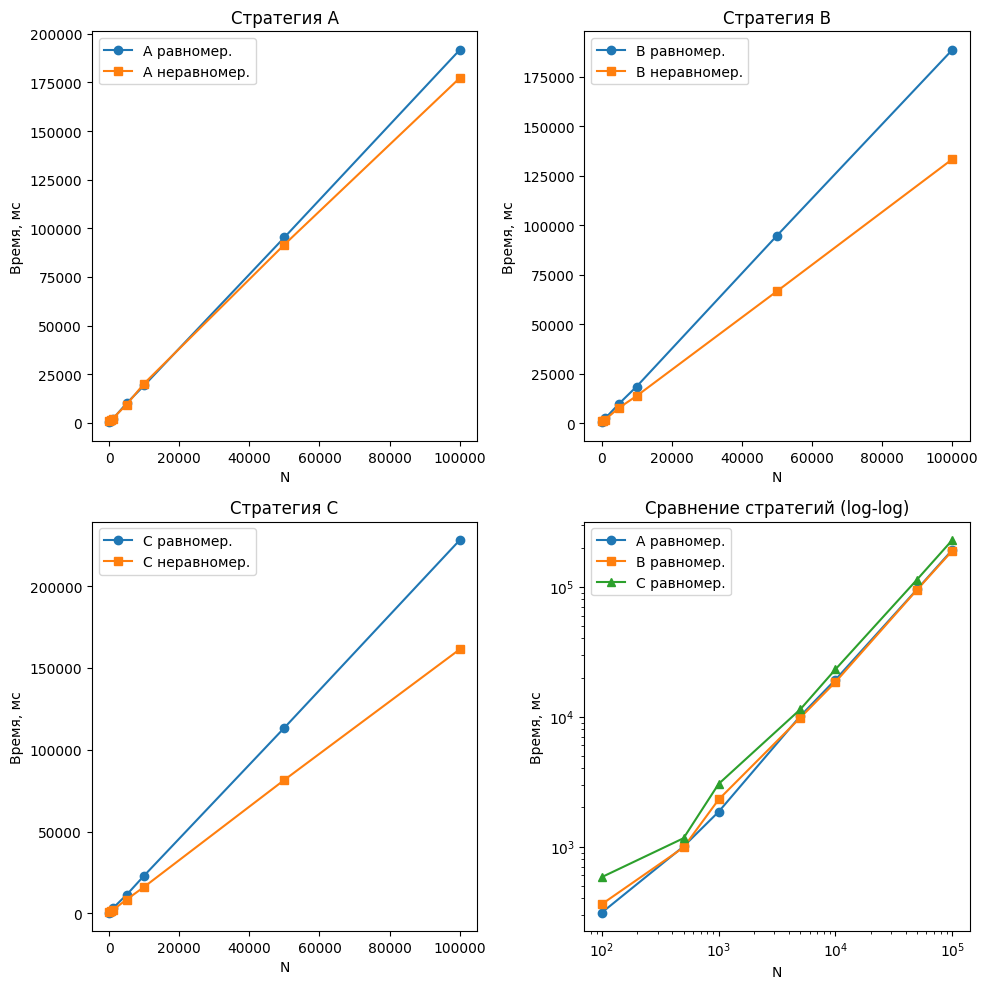

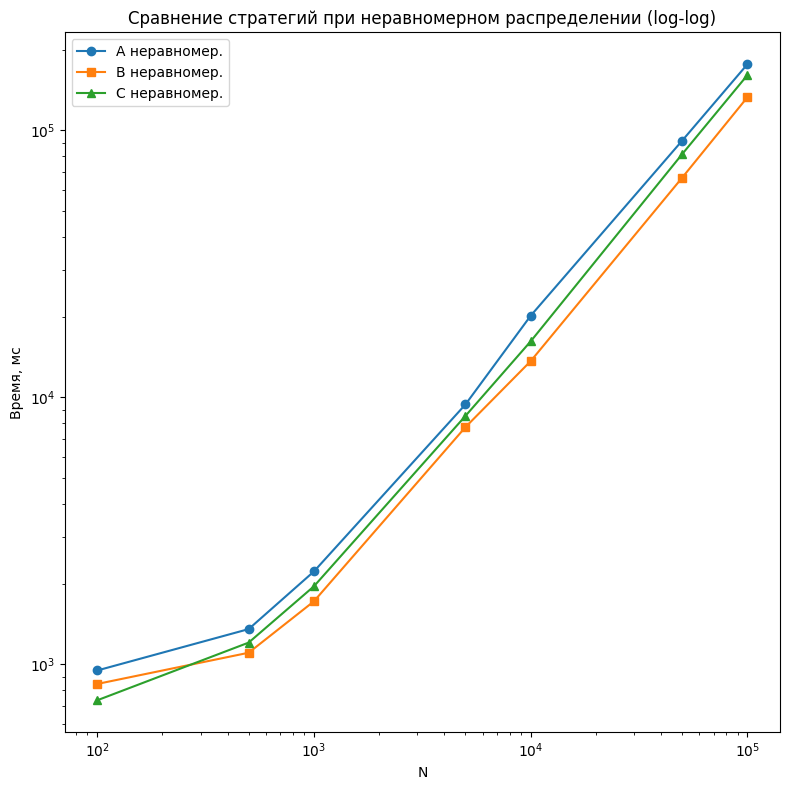

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Функция для загрузки и построения графика для одной стратегии
def plot_strategy(ax, file_uniform, file_nonuniform, label):
    data_unif = np.loadtxt(file_uniform)
    data_nonunif = np.loadtxt(file_nonuniform)
    ax.plot(data_unif[:,0], data_unif[:,1], 'o-', label=f'{label} равномер.')
    ax.plot(data_nonunif[:,0], data_nonunif[:,1], 's-', label=f'{label} неравномер.')
    ax.set_xlabel('N')
    ax.set_ylabel('Время, мс')
    ax.legend()

# --- Рисунок 1: четыре подграфика ---
fig, axes = plt.subplots(2, 2, figsize=(10, 10))  # квадратная фигура 2x2

# Стратегия A
plot_strategy(axes[0, 0], 'strategyA_uniform.txt', 'strategyA_nonuniform.txt', 'A')
axes[0, 0].set_title('Стратегия A')

# Стратегия B
plot_strategy(axes[0, 1], 'strategyB_uniform.txt', 'strategyB_nonuniform.txt', 'B')
axes[0, 1].set_title('Стратегия B')

# Стратегия C
plot_strategy(axes[1, 0], 'strategyC_uniform.txt', 'strategyC_nonuniform.txt', 'C')
axes[1, 0].set_title('Стратегия C')

# Совместный log-log график для равномерного распределения
data_A = np.loadtxt('strategyA_uniform.txt')
data_B = np.loadtxt('strategyB_uniform.txt')
data_C = np.loadtxt('strategyC_uniform.txt')
axes[1, 1].loglog(data_A[:,0], data_A[:,1], 'o-', label='A равномер.')
axes[1, 1].loglog(data_B[:,0], data_B[:,1], 's-', label='B равномер.')
axes[1, 1].loglog(data_C[:,0], data_C[:,1], '^-', label='C равномер.')
axes[1, 1].set_xlabel('N')
axes[1, 1].set_ylabel('Время, мс')
axes[1, 1].legend()
axes[1, 1].set_title('Сравнение стратегий (log-log)')

plt.tight_layout()
plt.savefig('lab3_strategies.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Рисунок 2: только неравномерное распределение в log-log ---
fig2, ax2 = plt.subplots(figsize=(8, 8))  # квадратный одиночный график

data_A_n = np.loadtxt('strategyA_nonuniform.txt')
data_B_n = np.loadtxt('strategyB_nonuniform.txt')
data_C_n = np.loadtxt('strategyC_nonuniform.txt')
ax2.loglog(data_A_n[:,0], data_A_n[:,1], 'o-', label='A неравномер.')
ax2.loglog(data_B_n[:,0], data_B_n[:,1], 's-', label='B неравномер.')
ax2.loglog(data_C_n[:,0], data_C_n[:,1], '^-', label='C неравномер.')
ax2.set_xlabel('N')
ax2.set_ylabel('Время, мс')
ax2.legend()
ax2.set_title('Сравнение стратегий при неравномерном распределении (log-log)')

plt.tight_layout()
plt.savefig('lab3_nonuniform.png', dpi=300, bbox_inches='tight')
plt.show()